In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

dataset = "ag_news"
seed = 2025
selected_dp_percent = [i for i in range(1, 101)]
iteration = 500


def plot_data_selection(seed, dataset, train_data, g, iteration=500):
    """Plot 9-subplot data-selection figure for one (dataset, train_data) setting.

    Looks up the following variables from g (caller's globals()):
      - seed{seed}_{dataset}_{train_data}_inv_lam1e_6
      - seed{seed}_{dataset}_{train_data}_r{R}_eigen1e_2_inv1e_6     (R in ranks)
      - seed{seed}_{dataset}_{train_data}_r{R}_eigen1e_2_eigen1e_2   (R in ranks)
      - seed{seed}_{dataset}_{train_data}_A_BASE
      - seed{seed}_{dataset}_{train_data}_inv_early_stop
      - seed{seed}_{dataset}_{train_data}_topr_early_stop
      - selected_dp_percent  (shared)
    """
    selected_dp_percent = g["selected_dp_percent"]
    inv             = g[f"seed{seed}_{dataset}_{train_data}_inv_lam1e_6"]
    A_BASE          = g[f"seed{seed}_{dataset}_{train_data}_A_BASE"]
    inv_early_stop  = g[f"seed{seed}_{dataset}_{train_data}_inv_early_stop"]
    topr_early_stop = g[f"seed{seed}_{dataset}_{train_data}_topr_early_stop"]

    ranks = [1, 5, 10, 15, 20, 25, 30]
    eigen_data_1 = [(g[f"seed{seed}_{dataset}_{train_data}_r{r}_eigen1e_2_eigen1e_2"], f"rank {r}%") for r in ranks]
    eigen_data_2 = [(g[f"seed{seed}_{dataset}_{train_data}_r{r}_eigen1e_2_inv1e_6"],   f"rank {r}%") for r in ranks]
    diff_data    = [(np.array(d1) - np.array(d2), lab)
                    for (d1, lab), (d2, _) in zip(eigen_data_1, eigen_data_2)]

    num_dp = train_data
    ZOOM_PCT = 20
    ZOOM_N = ZOOM_PCT

    fig, axes = plt.subplots(3, 3, figsize=(30, 28))
    axes = axes.flatten()

    inv_color = "red"
    eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

    # ===== Subplot (1,1): Eigen mode (shapley + prediction) - 1~ZOOM_PCT% =====
    ax1 = axes[0]
    plot_percent_10 = selected_dp_percent[:ZOOM_N]
    ax1.plot(plot_percent_10, inv[:ZOOM_N], color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=10, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_1):
        ax1.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=10, label=label, alpha=0.85)

    all_data_10_eigen = [inv[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_1]
    y_min_10 = min(min(d) for d in all_data_10_eigen)
    y_max_10 = max(max(d) for d in all_data_10_eigen)
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ylim_10_min = y_min_10 - y_margin_10
    ylim_10_max = y_max_10 + y_margin_10

    ax1.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax1.set_ylabel("Accuracy", fontsize=20)
    ax1.set_title(f"Eigen Shapley + Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax1.legend(fontsize=20, loc="best")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax1.set_ylim(ylim_10_min, ylim_10_max)
    ax1.tick_params(axis="both", labelsize=18)

    # ===== Subplot (1,2): Eigen shapley + INV prediction - 1~ZOOM_PCT% =====
    ax2 = axes[1]
    ax2.plot(plot_percent_10, inv[:ZOOM_N], color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=10, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_2):
        ax2.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=10, label=label, alpha=0.85)

    all_data_10_inv = [inv[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_2]
    y_min_10_inv = min(min(d) for d in all_data_10_inv)
    y_max_10_inv = max(max(d) for d in all_data_10_inv)
    ylim_10_min = min(ylim_10_min, y_min_10_inv - (y_max_10_inv - y_min_10_inv) * 0.1)
    ylim_10_max = max(ylim_10_max, y_max_10_inv + (y_max_10_inv - y_min_10_inv) * 0.1)

    ax2.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax2.set_ylabel("Accuracy", fontsize=20)
    ax2.set_title(f"Eigen Shapley + INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax2.legend(fontsize=20, loc="best")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax2.set_ylim(ylim_10_min, ylim_10_max)
    ax2.tick_params(axis="both", labelsize=18)

    ax1.set_ylim(ylim_10_min, ylim_10_max)

    # ===== Subplot (1,3): Difference (Eigen - INV) - 1~100% =====
    ax3 = axes[2]
    for i, (data, label) in enumerate(diff_data):
        ax3.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="d", markersize=6, label=label, alpha=0.85)

    all_diff_data = [d[0] for d in diff_data]
    y_min_diff = min(min(d) for d in all_diff_data)
    y_max_diff = max(max(d) for d in all_diff_data)
    y_margin_diff = max(abs(y_min_diff), abs(y_max_diff)) * 0.1
    ylim_diff_min = y_min_diff - y_margin_diff
    ylim_diff_max = y_max_diff + y_margin_diff

    ax3.axhline(y=0, color="black", linestyle="--", linewidth=1.5, alpha=0.5)
    ax3.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax3.set_ylabel("Accuracy Difference", fontsize=20)
    ax3.set_title(f"Difference (Eigen Pred - INV Pred) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax3.legend(fontsize=20, loc="best")
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, 101)
    ax3.set_ylim(ylim_diff_min, ylim_diff_max)
    ax3.tick_params(axis="both", labelsize=18)

    # ===== Subplot (2,1): Eigen mode (shapley + prediction) - 1~100% =====
    ax4 = axes[3]
    ax4.plot(selected_dp_percent, inv, color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=6, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_1):
        ax4.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=6, label=label, alpha=0.85)

    all_data_100_eigen = [inv] + [d[0] for d in eigen_data_1]
    y_min_100 = min(min(d) for d in all_data_100_eigen)
    y_max_100 = max(max(d) for d in all_data_100_eigen)
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ylim_100_min = y_min_100 - y_margin_100
    ylim_100_max = y_max_100 + y_margin_100

    ax4.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax4.set_ylabel("Accuracy", fontsize=20)
    ax4.set_title(f"Eigen Shapley + Eigen Pred (1-100%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax4.legend(fontsize=20, loc="best")
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim(0, 101)
    ax4.set_ylim(ylim_100_min, ylim_100_max)
    ax4.tick_params(axis="both", labelsize=18)

    # ===== Subplot (2,2): Eigen shapley + INV prediction - 1~100% =====
    ax5 = axes[4]
    ax5.plot(selected_dp_percent, inv, color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=6, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_2):
        ax5.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=6, label=label, alpha=0.85)

    all_data_100_inv = [inv] + [d[0] for d in eigen_data_2]
    y_min_100_inv = min(min(d) for d in all_data_100_inv)
    y_max_100_inv = max(max(d) for d in all_data_100_inv)
    ylim_100_min = min(ylim_100_min, y_min_100_inv - (y_max_100_inv - y_min_100_inv) * 0.1)
    ylim_100_max = max(ylim_100_max, y_max_100_inv + (y_max_100_inv - y_min_100_inv) * 0.1)

    ax5.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax5.set_ylabel("Accuracy", fontsize=20)
    ax5.set_title(f"Eigen Shapley + INV Pred (1-100%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax5.legend(fontsize=20, loc="best")
    ax5.grid(True, alpha=0.3)
    ax5.set_xlim(0, 101)
    ax5.set_ylim(ylim_100_min, ylim_100_max)
    ax5.tick_params(axis="both", labelsize=18)

    ax4.set_ylim(ylim_100_min, ylim_100_max)

    # ===== Subplot (2,3): Early Stop Ratio =====
    ax6 = axes[5]
    method_names = ["INV"] + [f"rank {r}%" for r in ranks]
    method_values = [inv_early_stop[0]] + list(topr_early_stop)
    bar_colors = [inv_color] + list(eigen_colors)
    x_pos = np.arange(len(method_names))
    bars = ax6.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor="black", linewidth=1.2)
    for bar, value in zip(bars, method_values):
        ax6.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                 f"{value:.2f}", ha="center", va="bottom", fontsize=20, fontweight="bold")
    ax6.set_xlabel("Method", fontsize=20)
    ax6.set_ylabel("Early Stop Ratio (%)", fontsize=20)
    ax6.set_title(f"Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(method_names, fontsize=20)
    ax6.grid(True, alpha=0.3, axis="y")
    ax6.tick_params(axis="y", labelsize=18)

    # ===== Subplot (3,1): ER for Eigen Pred - 1~ZOOM_PCT% =====
    ax7 = axes[6]
    inv_zoom_arr = np.array(inv[:ZOOM_N])

    er_data_eigen = []
    for i, (data, label) in enumerate(eigen_data_1):
        ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
        er_data_eigen.append((ers, f"{label} ({np.mean(ers):.3f}±{np.std(ers):.3f})"))

    for i, (ers, label) in enumerate(er_data_eigen):
        ax7.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=10, label=label, alpha=0.85)
    ax7.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, label="y=1 (baseline)")
    ax7.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax7.set_ylabel("Excess Retention (ER)", fontsize=20)
    ax7.set_title(f"ER: Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax7.legend(fontsize=20, loc="best")
    ax7.grid(True, alpha=0.3)
    ax7.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax7.tick_params(axis="both", labelsize=18)

    # ===== Subplot (3,2): ER for INV Pred - 1~ZOOM_PCT% =====
    ax8 = axes[7]
    er_data_inv = []
    for i, (data, label) in enumerate(eigen_data_2):
        ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
        er_data_inv.append((ers, f"{label} ({np.mean(ers):.3f}±{np.std(ers):.3f})"))

    for i, (ers, label) in enumerate(er_data_inv):
        ax8.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=10, label=label, alpha=0.85)
    ax8.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, label="y=1 (baseline)")
    ax8.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax8.set_ylabel("Excess Retention (ER)", fontsize=20)
    ax8.set_title(f"ER: INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax8.legend(fontsize=20, loc="best")
    ax8.grid(True, alpha=0.3)
    ax8.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax8.tick_params(axis="both", labelsize=18)

    # ===== Subplot (3,3): Turn off =====
    axes[8].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:

# ===== Configuration =====
num_dp = 1000
# =========================

seed2025_ag_news_1000_A_BASE = 

seed2025_ag_news_1000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2025_ag_news_1000_r1_eigen1e_2_inv1e_6  = 
seed2025_ag_news_1000_r5_eigen1e_2_inv1e_6  = 
seed2025_ag_news_1000_r10_eigen1e_2_inv1e_6 = 
seed2025_ag_news_1000_r15_eigen1e_2_inv1e_6 = 
seed2025_ag_news_1000_r20_eigen1e_2_inv1e_6 = 
seed2025_ag_news_1000_r25_eigen1e_2_inv1e_6 = 
seed2025_ag_news_1000_r30_eigen1e_2_inv1e_6 = 

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2025_ag_news_1000_r1_eigen1e_2_eigen1e_2  = 
seed2025_ag_news_1000_r5_eigen1e_2_eigen1e_2  = 
seed2025_ag_news_1000_r10_eigen1e_2_eigen1e_2 = 
seed2025_ag_news_1000_r15_eigen1e_2_eigen1e_2 = 
seed2025_ag_news_1000_r20_eigen1e_2_eigen1e_2 = 
seed2025_ag_news_1000_r25_eigen1e_2_eigen1e_2 = 
seed2025_ag_news_1000_r30_eigen1e_2_eigen1e_2 = 

seed2025_ag_news_1000_inv_early_stop  = []
seed2025_ag_news_1000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
# =========================

seed2025_ag_news_2000_A_BASE = 

seed2025_ag_news_2000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2025_ag_news_2000_r1_eigen1e_2_inv1e_6  = 
seed2025_ag_news_2000_r5_eigen1e_2_inv1e_6  = 
seed2025_ag_news_2000_r10_eigen1e_2_inv1e_6 = 
seed2025_ag_news_2000_r15_eigen1e_2_inv1e_6 = 
seed2025_ag_news_2000_r20_eigen1e_2_inv1e_6 = 
seed2025_ag_news_2000_r25_eigen1e_2_inv1e_6 = 
seed2025_ag_news_2000_r30_eigen1e_2_inv1e_6 = 

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2025_ag_news_2000_r1_eigen1e_2_eigen1e_2  = 
seed2025_ag_news_2000_r5_eigen1e_2_eigen1e_2  = 
seed2025_ag_news_2000_r10_eigen1e_2_eigen1e_2 = 
seed2025_ag_news_2000_r15_eigen1e_2_eigen1e_2 = 
seed2025_ag_news_2000_r20_eigen1e_2_eigen1e_2 = 
seed2025_ag_news_2000_r25_eigen1e_2_eigen1e_2 = 
seed2025_ag_news_2000_r30_eigen1e_2_eigen1e_2 = 

seed2025_ag_news_2000_inv_early_stop  = []
seed2025_ag_news_2000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


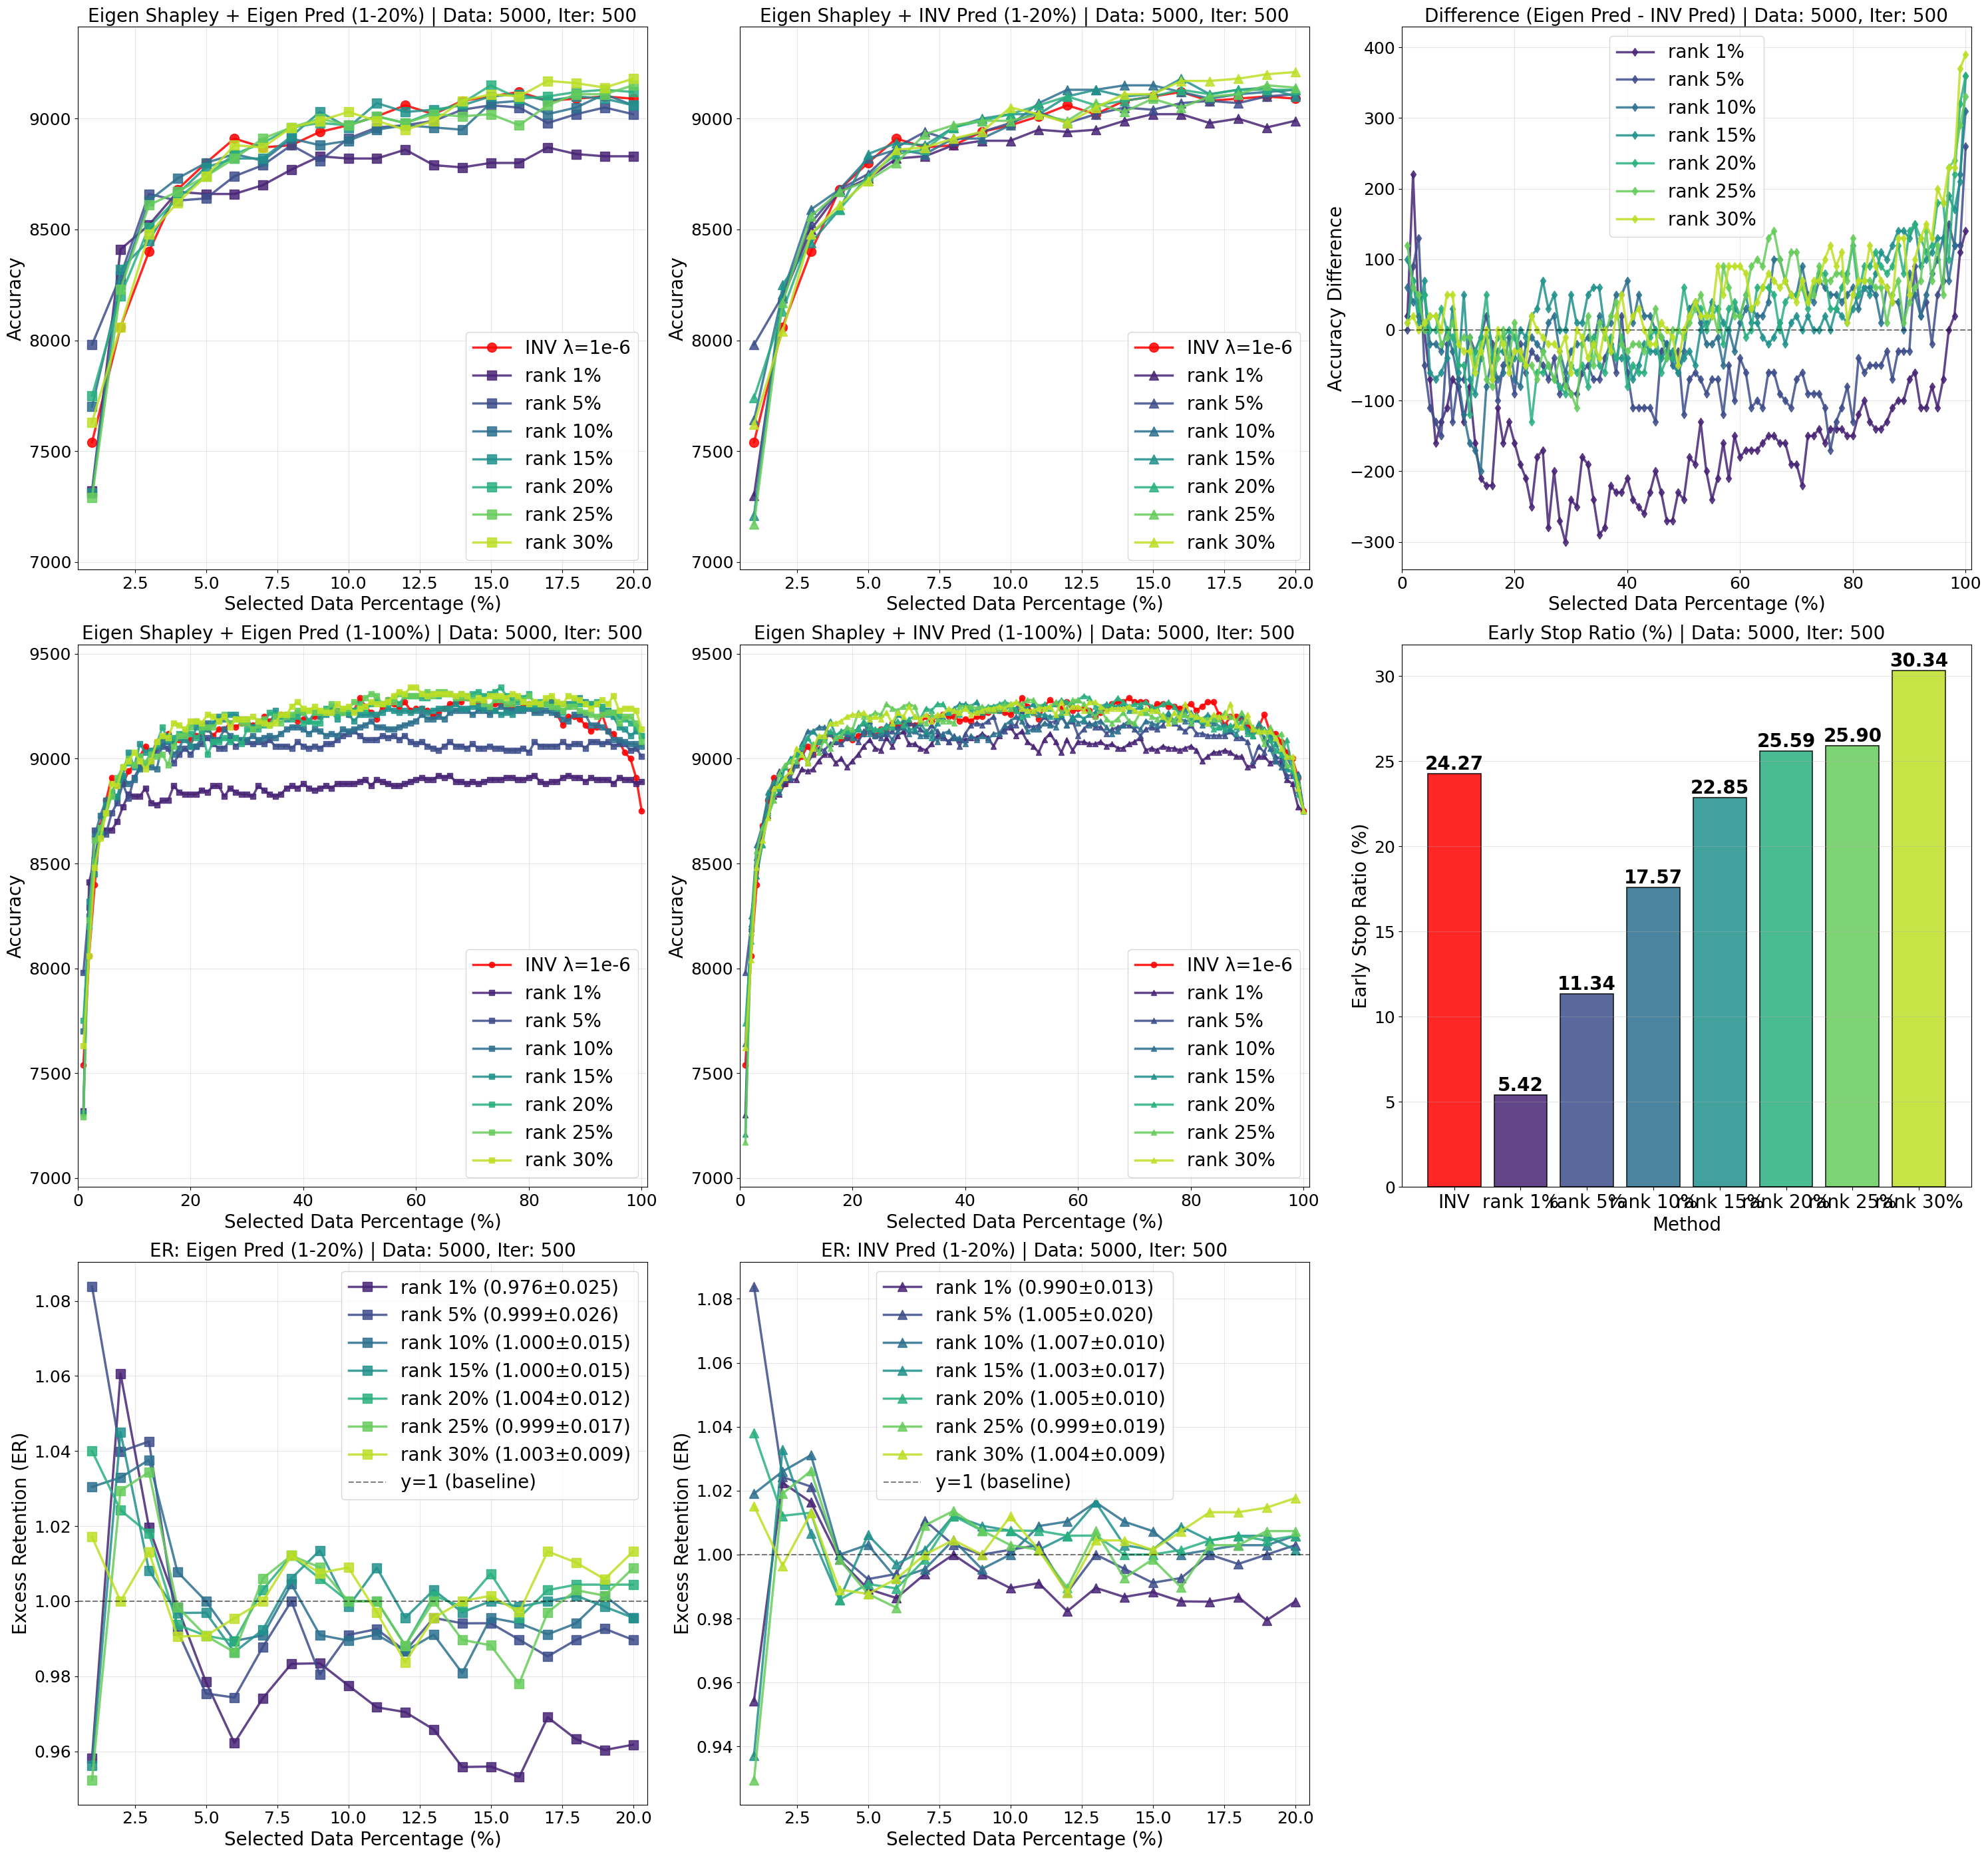

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
# =========================

seed2025_ag_news_5000_A_BASE = 2290

seed2025_ag_news_5000_inv_lam1e_6           = [7540, 8060, 8400, 8680, 8800, 8910, 8870, 8880, 8940, 8970, 9010, 9060, 9020, 9080, 9100, 9120, 9080, 9090, 9100, 9090, 9110, 9120, 9140, 9110, 9140, 9140, 9170, 9150, 9170, 9170, 9160, 9170, 9200, 9180, 9200, 9210, 9200, 9200, 9180, 9190, 9180, 9200, 9200, 9220, 9230, 9230, 9220, 9210, 9230, 9290, 9250, 9220, 9190, 9250, 9280, 9260, 9240, 9270, 9230, 9240, 9240, 9230, 9200, 9220, 9240, 9260, 9270, 9270, 9290, 9270, 9270, 9270, 9240, 9260, 9260, 9250, 9250, 9240, 9250, 9260, 9230, 9250, 9270, 9270, 9210, 9160, 9200, 9200, 9190, 9160, 9130, 9150, 9210, 9130, 9120, 9080, 9030, 9000, 8910, 8750]
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2025_ag_news_5000_r1_eigen1e_2_inv1e_6  = [7300, 8190, 8500, 8670, 8730, 8820, 8830, 8880, 8900, 8900, 8950, 8940, 8950, 8990, 9020, 9020, 8980, 9000, 8960, 8990, 9020, 9060, 9090, 9050, 9040, 9100, 9060, 9110, 9130, 9070, 9070, 9050, 9040, 9070, 9110, 9110, 9080, 9100, 9090, 9090, 9100, 9100, 9120, 9100, 9060, 9110, 9150, 9150, 9110, 9130, 9080, 9060, 9030, 9090, 9120, 9080, 9030, 9090, 9040, 9080, 9080, 9070, 9070, 9080, 9060, 9070, 9050, 9050, 9070, 9080, 9100, 9040, 9050, 9040, 9060, 9050, 9050, 9040, 9050, 9060, 9040, 8990, 9010, 9030, 9030, 9040, 9030, 9010, 9010, 8960, 8970, 9010, 9010, 8980, 8990, 8980, 8900, 8880, 8770, 8750]
seed2025_ag_news_5000_r5_eigen1e_2_inv1e_6  = [7980, 8200, 8530, 8680, 8750, 8870, 8940, 8900, 8940, 8980, 9030, 8980, 9020, 9050, 9040, 9070, 9080, 9070, 9100, 9110, 9080, 9130, 9130, 9110, 9100, 9120, 9130, 9150, 9150, 9170, 9160, 9140, 9120, 9160, 9130, 9100, 9080, 9110, 9060, 9120, 9160, 9170, 9160, 9180, 9200, 9120, 9130, 9160, 9160, 9230, 9160, 9150, 9160, 9200, 9170, 9180, 9210, 9160, 9180, 9110, 9140, 9170, 9150, 9150, 9120, 9140, 9150, 9160, 9160, 9140, 9110, 9140, 9150, 9140, 9160, 9210, 9170, 9150, 9130, 9160, 9120, 9120, 9110, 9110, 9110, 9110, 9130, 9100, 9100, 9080, 8990, 9060, 9030, 9100, 9010, 9000, 8920, 8920, 8930, 8750]
seed2025_ag_news_5000_r10_eigen1e_2_inv1e_6 = [7640, 8210, 8590, 8680, 8820, 8860, 8840, 8910, 8910, 8970, 9070, 9130, 9130, 9150, 9150, 9120, 9090, 9110, 9120, 9130, 9140, 9120, 9180, 9110, 9120, 9130, 9090, 9130, 9150, 9120, 9130, 9110, 9110, 9130, 9080, 9120, 9130, 9100, 9100, 9070, 9110, 9090, 9110, 9090, 9120, 9120, 9160, 9180, 9200, 9180, 9130, 9140, 9140, 9170, 9160, 9150, 9200, 9160, 9200, 9170, 9180, 9160, 9170, 9180, 9150, 9120, 9130, 9160, 9180, 9160, 9140, 9180, 9170, 9160, 9190, 9190, 9180, 9190, 9180, 9180, 9190, 9160, 9170, 9170, 9200, 9130, 9140, 9170, 9210, 9130, 9110, 9140, 9100, 9050, 8990, 8960, 9010, 8950, 8850, 8750]
seed2025_ag_news_5000_r15_eigen1e_2_inv1e_6 = [7210, 8250, 8440, 8590, 8840, 8890, 8880, 8960, 9000, 9020, 9020, 9100, 9130, 9100, 9110, 9180, 9110, 9130, 9140, 9100, 9150, 9170, 9120, 9140, 9130, 9160, 9160, 9210, 9190, 9140, 9140, 9170, 9130, 9100, 9170, 9200, 9220, 9240, 9260, 9260, 9250, 9270, 9220, 9240, 9250, 9230, 9250, 9240, 9240, 9250, 9240, 9260, 9210, 9210, 9200, 9200, 9210, 9230, 9190, 9210, 9190, 9210, 9220, 9250, 9260, 9250, 9250, 9260, 9230, 9230, 9250, 9220, 9240, 9230, 9190, 9220, 9180, 9220, 9230, 9220, 9190, 9190, 9210, 9190, 9150, 9160, 9140, 9120, 9150, 9140, 9110, 9170, 9140, 9120, 9070, 9020, 8950, 8940, 8920, 8750]
seed2025_ag_news_5000_r20_eigen1e_2_inv1e_6 = [7740, 8130, 8480, 8590, 8740, 8840, 8860, 8960, 8990, 9020, 9060, 9100, 9060, 9080, 9100, 9130, 9110, 9130, 9130, 9130, 9140, 9180, 9150, 9140, 9140, 9150, 9150, 9180, 9160, 9190, 9200, 9190, 9240, 9230, 9260, 9260, 9220, 9230, 9210, 9250, 9230, 9230, 9230, 9250, 9250, 9260, 9270, 9260, 9230, 9200, 9210, 9220, 9250, 9260, 9240, 9260, 9280, 9270, 9260, 9280, 9300, 9290, 9250, 9240, 9250, 9260, 9290, 9270, 9250, 9260, 9260, 9270, 9250, 9240, 9260, 9270, 9250, 9210, 9210, 9190, 9210, 9180, 9170, 9140, 9150, 9140, 9160, 9150, 9180, 9120, 9110, 9140, 9140, 9090, 9040, 9020, 9090, 8950, 8830, 8750]
seed2025_ag_news_5000_r25_eigen1e_2_inv1e_6 = [7170, 8170, 8560, 8670, 8720, 8800, 8930, 8970, 8990, 8990, 9020, 8990, 9070, 9030, 9090, 9050, 9100, 9110, 9150, 9140, 9220, 9200, 9200, 9220, 9210, 9260, 9240, 9230, 9250, 9260, 9250, 9180, 9170, 9210, 9190, 9180, 9180, 9170, 9250, 9250, 9250, 9240, 9250, 9230, 9230, 9240, 9260, 9240, 9270, 9260, 9280, 9280, 9250, 9240, 9250, 9270, 9220, 9240, 9280, 9280, 9260, 9230, 9200, 9230, 9190, 9170, 9190, 9220, 9180, 9170, 9220, 9220, 9200, 9190, 9210, 9190, 9180, 9210, 9210, 9170, 9200, 9190, 9190, 9190, 9190, 9220, 9200, 9180, 9220, 9180, 9150, 9130, 9070, 9150, 9100, 9120, 8970, 8960, 8880, 8750]
seed2025_ag_news_5000_r30_eigen1e_2_inv1e_6 = [7620, 8040, 8480, 8610, 8720, 8860, 8870, 8910, 8940, 9050, 9020, 8980, 9050, 9110, 9110, 9170, 9170, 9180, 9200, 9210, 9210, 9220, 9190, 9200, 9190, 9220, 9170, 9220, 9200, 9250, 9200, 9190, 9210, 9180, 9210, 9210, 9240, 9230, 9220, 9240, 9210, 9220, 9230, 9240, 9240, 9250, 9240, 9260, 9270, 9240, 9230, 9230, 9240, 9240, 9250, 9210, 9270, 9220, 9250, 9250, 9230, 9270, 9270, 9250, 9230, 9240, 9240, 9240, 9250, 9230, 9220, 9240, 9230, 9230, 9200, 9170, 9220, 9190, 9260, 9210, 9200, 9190, 9170, 9210, 9200, 9200, 9260, 9160, 9150, 9210, 9140, 9130, 9130, 9130, 9100, 9050, 9010, 9010, 8860, 8750]

# Predction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2025_ag_news_5000_r1_eigen1e_2_eigen1e_2  = [7320, 8410, 8520, 8670, 8660, 8660, 8700, 8770, 8830, 8820, 8820, 8860, 8790, 8780, 8800, 8800, 8870, 8840, 8830, 8830, 8830, 8850, 8840, 8870, 8870, 8820, 8860, 8840, 8830, 8830, 8820, 8870, 8850, 8830, 8820, 8830, 8860, 8870, 8860, 8880, 8860, 8850, 8860, 8870, 8860, 8880, 8880, 8880, 8880, 8890, 8900, 8870, 8900, 8890, 8880, 8870, 8870, 8880, 8890, 8900, 8910, 8900, 8900, 8920, 8910, 8920, 8890, 8890, 8880, 8890, 8880, 8890, 8900, 8900, 8900, 8910, 8910, 8900, 8900, 8910, 8920, 8890, 8880, 8890, 8890, 8910, 8920, 8910, 8910, 8890, 8910, 8900, 8900, 8900, 8880, 8910, 8900, 8900, 8880, 8890]
seed2025_ag_news_5000_r5_eigen1e_2_eigen1e_2  = [7980, 8290, 8660, 8630, 8640, 8740, 8790, 8880, 8810, 8910, 8960, 8970, 8990, 9040, 9060, 9050, 8980, 9020, 9050, 9020, 9060, 9070, 9100, 9070, 9050, 9050, 9090, 9060, 9080, 9080, 9070, 9080, 9070, 9090, 9060, 9060, 9060, 9050, 9080, 9060, 9050, 9060, 9050, 9070, 9070, 9090, 9110, 9120, 9130, 9110, 9090, 9090, 9090, 9110, 9100, 9110, 9090, 9110, 9080, 9070, 9080, 9060, 9050, 9040, 9060, 9080, 9060, 9060, 9050, 9070, 9050, 9050, 9060, 9050, 9050, 9040, 9040, 9040, 9050, 9030, 9080, 9060, 9060, 9060, 9060, 9080, 9060, 9070, 9070, 9050, 9080, 9080, 9070, 9080, 9060, 9070, 9070, 9040, 9050, 9010]
seed2025_ag_news_5000_r10_eigen1e_2_eigen1e_2 = [7700, 8250, 8630, 8730, 8800, 8840, 8810, 8910, 8880, 8900, 8950, 8970, 8960, 8950, 9070, 9080, 9020, 9050, 9110, 9060, 9060, 9100, 9170, 9090, 9090, 9140, 9110, 9100, 9090, 9090, 9110, 9090, 9100, 9110, 9100, 9120, 9140, 9150, 9150, 9140, 9120, 9140, 9130, 9110, 9120, 9110, 9140, 9130, 9140, 9150, 9160, 9180, 9150, 9150, 9140, 9140, 9150, 9160, 9170, 9180, 9210, 9190, 9190, 9200, 9190, 9220, 9230, 9230, 9230, 9210, 9230, 9230, 9210, 9230, 9250, 9240, 9230, 9230, 9230, 9240, 9220, 9220, 9230, 9220, 9210, 9190, 9180, 9210, 9210, 9210, 9160, 9160, 9150, 9130, 9090, 9090, 9080, 9070, 9070, 9060]
seed2025_ag_news_5000_r15_eigen1e_2_eigen1e_2 = [7310, 8320, 8450, 8660, 8780, 8820, 8820, 8920, 9030, 8960, 9070, 9030, 9040, 9060, 9100, 9110, 9080, 9100, 9090, 9060, 9150, 9160, 9140, 9170, 9200, 9190, 9210, 9210, 9190, 9190, 9150, 9180, 9180, 9160, 9230, 9200, 9190, 9200, 9220, 9220, 9180, 9220, 9200, 9210, 9220, 9190, 9220, 9210, 9180, 9210, 9210, 9210, 9210, 9220, 9240, 9230, 9220, 9230, 9220, 9230, 9240, 9220, 9230, 9240, 9240, 9240, 9260, 9240, 9240, 9250, 9250, 9240, 9240, 9230, 9210, 9220, 9210, 9240, 9240, 9250, 9240, 9250, 9260, 9270, 9260, 9260, 9260, 9260, 9290, 9270, 9260, 9260, 9240, 9230, 9200, 9150, 9140, 9110, 9130, 9110]
seed2025_ag_news_5000_r20_eigen1e_2_eigen1e_2 = [7750, 8200, 8510, 8640, 8740, 8840, 8890, 8960, 8980, 8970, 9010, 8980, 9030, 9070, 9150, 9090, 9100, 9120, 9130, 9120, 9100, 9130, 9020, 9080, 9080, 9100, 9080, 9100, 9070, 9140, 9140, 9140, 9160, 9220, 9210, 9200, 9210, 9190, 9200, 9170, 9180, 9170, 9170, 9240, 9250, 9200, 9230, 9220, 9230, 9260, 9230, 9260, 9280, 9260, 9260, 9290, 9260, 9300, 9300, 9300, 9290, 9290, 9310, 9300, 9310, 9310, 9290, 9310, 9300, 9310, 9320, 9300, 9310, 9320, 9340, 9300, 9280, 9270, 9290, 9310, 9260, 9270, 9260, 9250, 9240, 9220, 9250, 9270, 9260, 9260, 9260, 9270, 9250, 9210, 9220, 9200, 9190, 9170, 9150, 9110]
seed2025_ag_news_5000_r25_eigen1e_2_eigen1e_2 = [7290, 8230, 8610, 8670, 8740, 8820, 8910, 8960, 9000, 8970, 9010, 8980, 9020, 9010, 9020, 8970, 9060, 9110, 9110, 9150, 9180, 9150, 9150, 9150, 9180, 9210, 9170, 9190, 9170, 9170, 9140, 9160, 9190, 9160, 9200, 9170, 9200, 9210, 9230, 9220, 9230, 9220, 9220, 9230, 9260, 9230, 9220, 9240, 9270, 9250, 9290, 9310, 9300, 9260, 9280, 9270, 9310, 9300, 9300, 9300, 9310, 9320, 9300, 9320, 9320, 9310, 9290, 9290, 9290, 9280, 9280, 9260, 9250, 9280, 9280, 9260, 9260, 9290, 9280, 9300, 9270, 9260, 9260, 9250, 9250, 9230, 9250, 9250, 9230, 9220, 9210, 9200, 9210, 9220, 9220, 9170, 9200, 9200, 9170, 9080]
seed2025_ag_news_5000_r30_eigen1e_2_eigen1e_2 = [7630, 8060, 8480, 8620, 8740, 8880, 8870, 8960, 8990, 9030, 8990, 8950, 8990, 9080, 9110, 9100, 9170, 9160, 9140, 9180, 9180, 9170, 9210, 9200, 9180, 9200, 9150, 9190, 9190, 9190, 9200, 9180, 9170, 9160, 9170, 9210, 9210, 9250, 9270, 9240, 9230, 9250, 9230, 9220, 9220, 9260, 9240, 9250, 9220, 9240, 9250, 9270, 9260, 9260, 9270, 9300, 9320, 9310, 9340, 9340, 9310, 9300, 9310, 9310, 9310, 9310, 9300, 9310, 9300, 9270, 9290, 9280, 9300, 9300, 9300, 9290, 9310, 9300, 9270, 9260, 9270, 9260, 9290, 9300, 9270, 9260, 9300, 9290, 9280, 9260, 9240, 9260, 9280, 9260, 9300, 9230, 9240, 9240, 9230, 9140]

seed2025_ag_news_5000_inv_early_stop  = [24.27]
seed2025_ag_news_5000_topr_early_stop = [ 5.42, 11.34, 17.57, 22.85, 25.59, 25.90, 30.34]

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


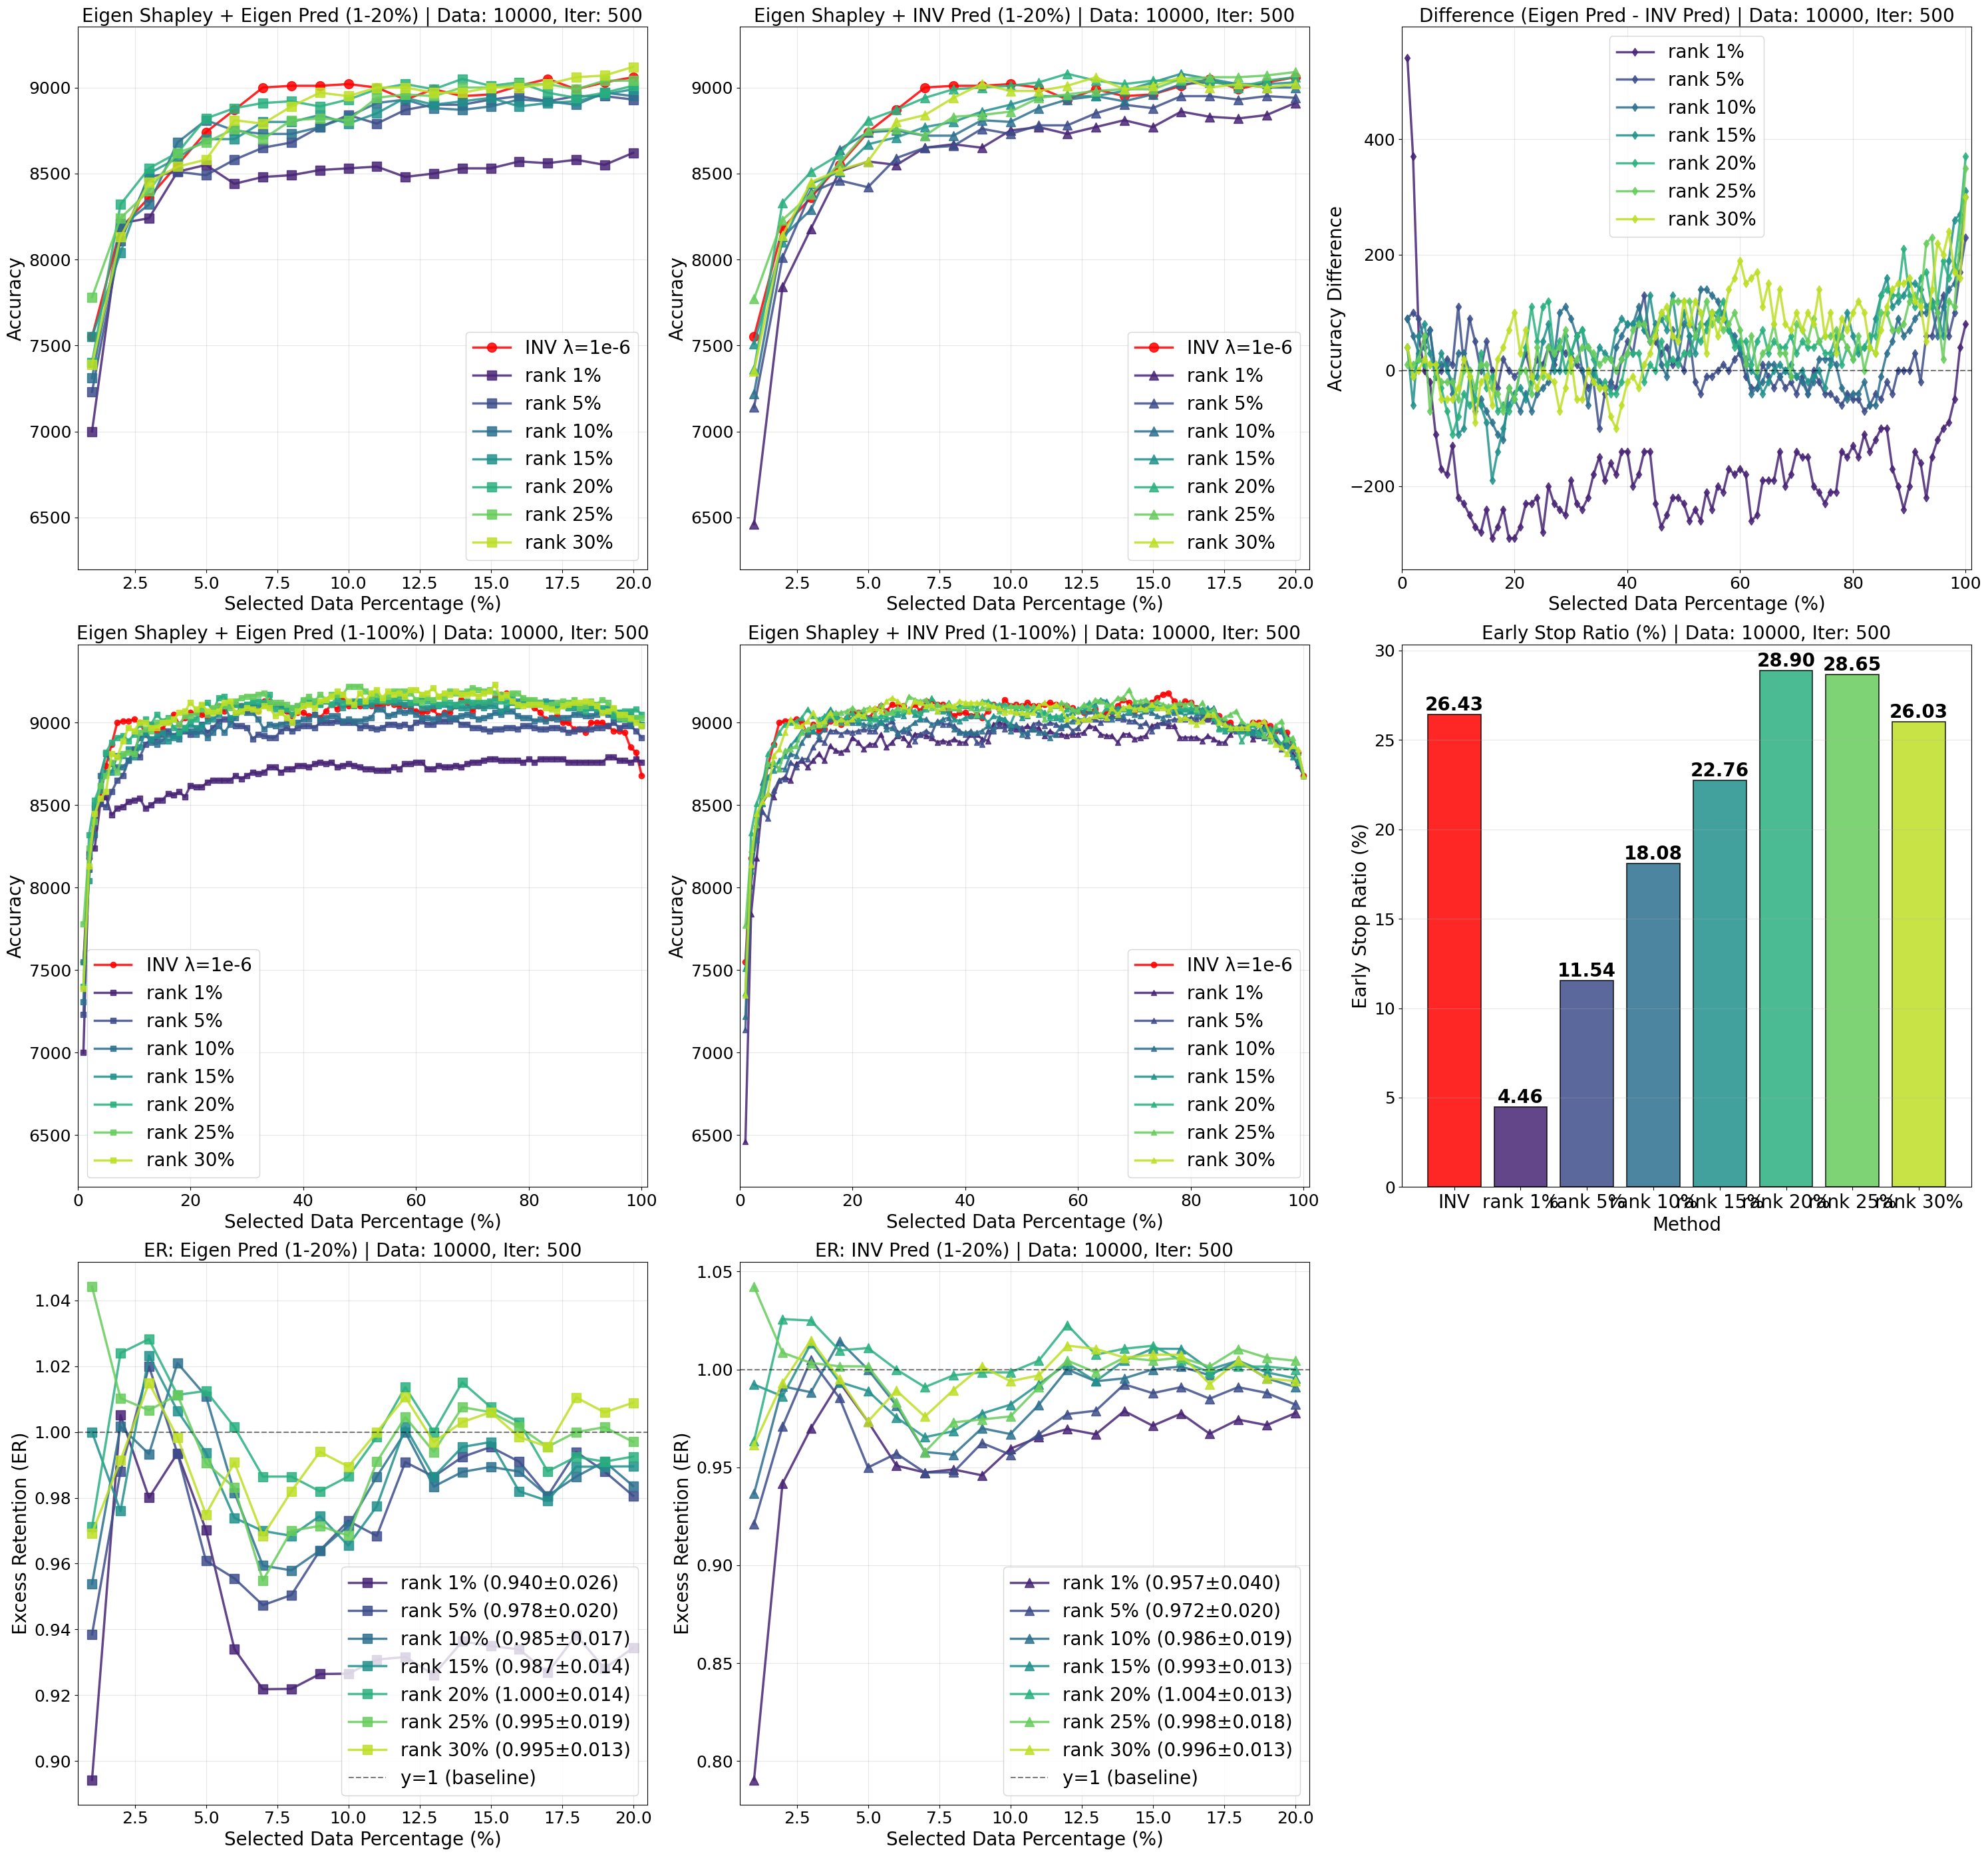

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 10000
# =========================

seed2025_ag_news_10000_A_BASE = 2350

seed2025_ag_news_10000_inv_lam1e_6           = [7550, 8180, 8360, 8550, 8740, 8870, 9000, 9010, 9010, 9020, 9000, 8930, 8990, 8950, 8960, 9010, 9050, 8990, 9030, 9060, 9060, 9050, 9030, 9080, 9100, 9070, 9110, 9110, 9100, 9070, 9110, 9070, 9130, 9130, 9110, 9110, 9070, 9040, 9060, 9060, 9040, 9050, 9030, 9070, 9110, 9080, 9140, 9100, 9110, 9100, 9120, 9100, 9100, 9110, 9120, 9110, 9100, 9100, 9090, 9070, 9060, 9070, 9080, 9040, 9060, 9060, 9100, 9140, 9120, 9070, 9100, 9100, 9120, 9150, 9170, 9180, 9130, 9110, 9130, 9120, 9090, 9060, 9020, 9030, 9040, 9000, 9000, 8960, 8960, 8940, 9000, 9000, 9000, 8980, 8950, 8950, 8940, 8850, 8820, 8680]
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2025_ag_news_10000_r1_eigen1e_2_inv1e_6  = [6460, 7840, 8180, 8510, 8570, 8550, 8650, 8670, 8650, 8750, 8770, 8730, 8770, 8810, 8770, 8860, 8830, 8820, 8840, 8910, 8880, 8840, 8870, 8870, 8930, 8850, 8880, 8920, 8910, 8870, 8930, 8930, 8920, 8910, 8880, 8890, 8880, 8900, 8880, 8880, 8930, 8930, 8900, 8890, 8990, 9000, 8990, 8970, 8960, 8960, 8980, 8960, 8970, 8920, 8950, 8930, 8930, 8920, 8930, 8930, 8940, 8980, 8970, 8930, 8920, 8920, 8880, 8930, 8930, 8900, 8910, 8920, 8980, 8990, 9000, 8980, 8980, 8910, 8910, 8910, 8910, 8890, 8920, 8900, 8880, 8880, 8930, 8960, 9000, 8960, 8900, 8920, 8980, 8940, 8910, 8870, 8860, 8810, 8740, 8680]
seed2025_ag_news_10000_r5_eigen1e_2_inv1e_6  = [7140, 8010, 8390, 8460, 8420, 8590, 8650, 8660, 8760, 8730, 8780, 8780, 8850, 8900, 8880, 8950, 8950, 8930, 8950, 8940, 8950, 8960, 8950, 8950, 9000, 8980, 9010, 8940, 8950, 8940, 8890, 8930, 8950, 8930, 9010, 8990, 8990, 8980, 8950, 8930, 8950, 8880, 8870, 8950, 8950, 8980, 8960, 8990, 8980, 8970, 8920, 8990, 9000, 8980, 9000, 8990, 8970, 8990, 8950, 8970, 9020, 9020, 9020, 9000, 9020, 9040, 9030, 9020, 9010, 9010, 8980, 9000, 8950, 8980, 9000, 9010, 9020, 9020, 9020, 9030, 9020, 9030, 9020, 9010, 9020, 8980, 8980, 8950, 8960, 8960, 8930, 8990, 8910, 8920, 8900, 8840, 8920, 8880, 8780, 8680]
seed2025_ag_news_10000_r10_eigen1e_2_inv1e_6 = [7220, 8130, 8290, 8640, 8740, 8750, 8720, 8720, 8810, 8800, 8880, 8930, 8950, 8920, 8960, 9020, 9030, 9020, 9000, 9000, 9000, 8990, 8980, 8980, 9010, 8960, 8970, 8930, 8960, 8970, 9000, 9020, 9020, 8990, 9000, 9020, 9030, 8960, 8940, 8940, 8940, 8940, 8950, 8980, 8960, 9030, 9020, 8950, 8990, 8930, 8940, 8960, 8940, 8940, 8910, 8930, 8980, 8990, 9010, 9020, 9020, 9070, 9050, 9050, 9040, 9020, 9040, 9040, 9060, 9050, 9040, 9070, 9060, 9040, 9030, 9050, 9060, 9070, 9080, 9070, 9050, 9040, 9070, 9090, 9030, 9000, 8980, 8960, 8990, 8970, 8950, 8950, 8960, 8940, 8970, 8950, 8880, 8840, 8820, 8680]
seed2025_ag_news_10000_r15_eigen1e_2_inv1e_6 = [7510, 8100, 8440, 8510, 8670, 8710, 8770, 8800, 8860, 8900, 8950, 8950, 8950, 8980, 9030, 9080, 9050, 9020, 9020, 9030, 9000, 9030, 9030, 9030, 9000, 9020, 9030, 9050, 9040, 9080, 9050, 9030, 9110, 9110, 9070, 9070, 9060, 9020, 9010, 9030, 9040, 9040, 9040, 9000, 9040, 9030, 9020, 8990, 9070, 9030, 9040, 9080, 9050, 9060, 9040, 9030, 9020, 9040, 9060, 9080, 9070, 9090, 9110, 9140, 9130, 9090, 9090, 9090, 9080, 9110, 9100, 9110, 9110, 9100, 9100, 9080, 9080, 9070, 9040, 9070, 9090, 9080, 9090, 9030, 8970, 8950, 8980, 8970, 8950, 8940, 8940, 8940, 8970, 8970, 8960, 8960, 8860, 8790, 8760, 8680]
seed2025_ag_news_10000_r20_eigen1e_2_inv1e_6 = [7360, 8330, 8510, 8610, 8810, 8870, 8940, 8990, 9000, 9010, 9030, 9080, 9040, 9020, 9040, 9040, 9040, 9000, 9040, 9060, 9020, 9060, 9010, 9020, 9040, 9040, 9070, 9060, 9070, 9080, 9070, 9060, 9080, 9150, 9110, 9090, 9120, 9090, 9100, 9100, 9100, 9090, 9130, 9130, 9110, 9110, 9110, 9100, 9090, 9090, 9100, 9080, 9090, 9060, 9030, 9040, 9040, 9080, 9080, 9080, 9100, 9120, 9080, 9040, 9090, 9070, 9070, 9080, 9070, 9090, 9080, 9080, 9090, 9090, 9100, 9090, 9100, 9090, 9080, 9090, 9070, 9070, 9050, 9030, 8960, 8960, 8960, 8970, 8890, 8940, 8990, 8930, 8920, 8960, 8920, 8870, 8910, 8890, 8820, 8680]
seed2025_ag_news_10000_r25_eigen1e_2_inv1e_6 = [7770, 8230, 8380, 8560, 8750, 8760, 8720, 8830, 8840, 8860, 8940, 8960, 8980, 8990, 8990, 9050, 9060, 9060, 9070, 9090, 9060, 9080, 9090, 9050, 9110, 9060, 9060, 9090, 9080, 9160, 9140, 9130, 9140, 9090, 9110, 9100, 9090, 9090, 9080, 9110, 9090, 9050, 9090, 9090, 9100, 9070, 9080, 9100, 9100, 9100, 9070, 9100, 9090, 9020, 9080, 9100, 9120, 9110, 9080, 9070, 9110, 9090, 9140, 9130, 9110, 9110, 9150, 9150, 9200, 9130, 9130, 9140, 9110, 9130, 9110, 9100, 9110, 9120, 9110, 9120, 9080, 9120, 9060, 9080, 9020, 9030, 9050, 9070, 9010, 8980, 9000, 8990, 8920, 8890, 8980, 9010, 8900, 8910, 8800, 8680]
seed2025_ag_news_10000_r30_eigen1e_2_inv1e_6 = [7350, 8140, 8450, 8520, 8570, 8800, 8840, 8940, 9020, 8980, 8980, 9010, 9060, 8990, 9010, 9060, 9000, 9020, 9000, 9020, 9050, 9040, 9080, 9090, 9070, 9130, 9150, 9130, 9100, 9070, 9130, 9120, 9100, 9110, 9070, 9090, 9110, 9100, 9130, 9120, 9120, 9120, 9120, 9110, 9100, 9090, 9060, 9070, 9060, 9060, 9050, 9060, 9100, 9120, 9090, 9110, 9090, 9020, 9040, 9010, 9020, 9020, 9040, 9050, 9030, 9090, 9050, 9090, 9100, 9080, 9090, 9080, 9110, 9090, 9090, 9070, 9100, 9020, 9030, 9010, 8990, 9010, 9050, 9050, 9000, 8990, 8970, 8970, 8970, 8970, 9000, 8990, 9010, 8930, 8870, 8850, 8810, 8860, 8840, 8680]

# Predction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2025_ag_news_10000_r1_eigen1e_2_eigen1e_2  = [7000, 8210, 8240, 8510, 8550, 8440, 8480, 8490, 8520, 8530, 8540, 8480, 8500, 8530, 8530, 8570, 8560, 8580, 8550, 8620, 8610, 8610, 8640, 8650, 8650, 8650, 8650, 8680, 8660, 8680, 8700, 8690, 8700, 8730, 8730, 8700, 8720, 8720, 8740, 8740, 8730, 8750, 8760, 8750, 8760, 8730, 8740, 8750, 8740, 8730, 8720, 8720, 8710, 8710, 8710, 8730, 8720, 8750, 8750, 8760, 8760, 8720, 8720, 8740, 8730, 8730, 8740, 8730, 8750, 8760, 8760, 8770, 8780, 8780, 8770, 8770, 8770, 8770, 8760, 8780, 8760, 8780, 8780, 8780, 8780, 8780, 8760, 8760, 8760, 8760, 8760, 8760, 8760, 8790, 8790, 8770, 8770, 8760, 8780, 8760]
seed2025_ag_news_10000_r5_eigen1e_2_eigen1e_2  = [7230, 8110, 8480, 8510, 8490, 8580, 8650, 8680, 8770, 8840, 8790, 8870, 8900, 8900, 8930, 8950, 8920, 8950, 8950, 8930, 8950, 8990, 8940, 8970, 9010, 9020, 9020, 8980, 8980, 8970, 8900, 8930, 8920, 8910, 8910, 8950, 8970, 8950, 8970, 8980, 8980, 8970, 9000, 9000, 9000, 9010, 9000, 9000, 9000, 8970, 8980, 8970, 8960, 8970, 8990, 8990, 8980, 8990, 8970, 9000, 9010, 8990, 8990, 9010, 9010, 9010, 9020, 8990, 8990, 8970, 8970, 8960, 8950, 8960, 8960, 8970, 8970, 8960, 8980, 8980, 8970, 8960, 8960, 8970, 8970, 8960, 8940, 8950, 8960, 8960, 8960, 8970, 8970, 8980, 9000, 8970, 8980, 8980, 8950, 8910]
seed2025_ag_news_10000_r10_eigen1e_2_eigen1e_2 = [7310, 8190, 8320, 8680, 8810, 8750, 8730, 8730, 8770, 8830, 8910, 8930, 8880, 8870, 8890, 8930, 8920, 8900, 8970, 8950, 8930, 8950, 8910, 8940, 8980, 8940, 8990, 9030, 9070, 9060, 9060, 9020, 8960, 8990, 8980, 8990, 9000, 9000, 9000, 9020, 9020, 9050, 9020, 9030, 9040, 9040, 9010, 9020, 9010, 9010, 9020, 9030, 9080, 9080, 9040, 9050, 9070, 9060, 9070, 9050, 9030, 9030, 9020, 9030, 9050, 9030, 9030, 9040, 9050, 9040, 9020, 9030, 9040, 9060, 9050, 9070, 9070, 9040, 9030, 9030, 9010, 9020, 9010, 9030, 9020, 9030, 9030, 9050, 9050, 9040, 9040, 9050, 9060, 9050, 9030, 9060, 9020, 8990, 9020, 8980]
seed2025_ag_news_10000_r15_eigen1e_2_eigen1e_2 = [7550, 8040, 8500, 8590, 8700, 8700, 8800, 8800, 8840, 8790, 8850, 8940, 8900, 8920, 8940, 8890, 8910, 8920, 8960, 8990, 8970, 8980, 9010, 9020, 9050, 9100, 9030, 9050, 9100, 9110, 9110, 9100, 9110, 9100, 9110, 9100, 9080, 9090, 9100, 9110, 9120, 9130, 9110, 9130, 9110, 9120, 9090, 9120, 9130, 9130, 9100, 9110, 9130, 9140, 9140, 9120, 9120, 9110, 9110, 9120, 9090, 9090, 9100, 9100, 9110, 9090, 9100, 9090, 9090, 9100, 9100, 9090, 9100, 9100, 9070, 9090, 9120, 9130, 9140, 9130, 9120, 9120, 9130, 9120, 9100, 9110, 9090, 9090, 9080, 9090, 9090, 9080, 9080, 9090, 9060, 9020, 9050, 9050, 9030, 8990]
seed2025_ag_news_10000_r20_eigen1e_2_eigen1e_2 = [7400, 8320, 8530, 8620, 8820, 8880, 8910, 8920, 8890, 8930, 8990, 9020, 8990, 9050, 9010, 9030, 8970, 8940, 8970, 9010, 9020, 9100, 9120, 9070, 9150, 9160, 9100, 9110, 9070, 9110, 9130, 9130, 9120, 9170, 9080, 9070, 9080, 9050, 9080, 9130, 9130, 9120, 9110, 9140, 9110, 9160, 9120, 9120, 9100, 9120, 9130, 9140, 9140, 9130, 9130, 9140, 9160, 9150, 9120, 9130, 9150, 9130, 9130, 9110, 9120, 9120, 9110, 9120, 9130, 9120, 9130, 9120, 9130, 9140, 9130, 9120, 9160, 9100, 9120, 9110, 9110, 9110, 9110, 9090, 9090, 9100, 9090, 9100, 9100, 9070, 9100, 9090, 9090, 9070, 9040, 9060, 9070, 9070, 9080, 9050]
seed2025_ag_news_10000_r25_eigen1e_2_eigen1e_2 = [7780, 8240, 8400, 8620, 8680, 8760, 8700, 8810, 8820, 8810, 8940, 8960, 8950, 9000, 9000, 9020, 9020, 8990, 9040, 9040, 9060, 9080, 9050, 9090, 9100, 9100, 9090, 9130, 9150, 9160, 9160, 9170, 9180, 9120, 9120, 9120, 9110, 9090, 9100, 9140, 9160, 9130, 9170, 9140, 9170, 9170, 9170, 9220, 9220, 9220, 9190, 9160, 9170, 9140, 9160, 9190, 9190, 9190, 9180, 9140, 9120, 9150, 9140, 9160, 9150, 9190, 9180, 9180, 9190, 9210, 9200, 9190, 9200, 9180, 9170, 9160, 9180, 9180, 9150, 9140, 9140, 9120, 9100, 9110, 9120, 9130, 9120, 9140, 9090, 9100, 9130, 9110, 9140, 9120, 9080, 9030, 9020, 9020, 9030, 9030]
seed2025_ag_news_10000_r30_eigen1e_2_eigen1e_2 = [7390, 8130, 8450, 8540, 8580, 8810, 8790, 8890, 8970, 8950, 9000, 9000, 8970, 8970, 9000, 9000, 9020, 9060, 9070, 9120, 9080, 9110, 9070, 9060, 9070, 9120, 9130, 9060, 9070, 9090, 9080, 9070, 9100, 9090, 9040, 9060, 9030, 9000, 9070, 9100, 9110, 9090, 9130, 9140, 9160, 9190, 9170, 9130, 9110, 9180, 9130, 9180, 9200, 9150, 9190, 9170, 9180, 9160, 9200, 9200, 9170, 9180, 9210, 9160, 9180, 9170, 9190, 9170, 9170, 9180, 9160, 9180, 9190, 9230, 9150, 9170, 9130, 9110, 9100, 9110, 9110, 9110, 9090, 9080, 9070, 9100, 9110, 9120, 9120, 9130, 9120, 9100, 9060, 9070, 9090, 9050, 9050, 9030, 9000, 8980]

seed2025_ag_news_10000_inv_early_stop  = [26.43]
seed2025_ag_news_10000_topr_early_stop = [ 4.46, 11.54, 18.08, 22.76, 28.90, 28.65, 26.03]

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)
